# Pertemuan 2: Data Preprocessing dan EDA


In [9]:
# Import library
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [10]:
# Memuat dataset Titanic
df = sns.load_dataset('titanic')
print('=== Ukuran Data Awal ===')
print('Shape:', df.shape)
print('\nTipe kolom:')
print(df.dtypes)

=== Ukuran Data Awal ===
Shape: (891, 15)

Tipe kolom:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


In [11]:
# 1. Missing Value
print('\n=== Missing Value (sebelum) ===')
print(df.isnull().sum()[df.isnull().sum() > 0])

df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
df['deck'] = df['deck'].cat.add_categories('Unknown').fillna('Unknown')

print('\n=== Missing Value (sesudah) ===')
print(df.isnull().sum()[df.isnull().sum() > 0])


=== Missing Value (sebelum) ===
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

=== Missing Value (sesudah) ===
Series([], dtype: int64)


In [12]:
# 2. Duplikat
print('\n=== Duplikat ===')
print('Jumlah duplikat:', df.duplicated().sum())
df = df.drop_duplicates()


=== Duplikat ===
Jumlah duplikat: 110


In [13]:
# 3. Outlier (IQR)
print('\n=== Outlier (IQR) ===')
for col in ['fare','age']:
    q1, q3 = df[col].quantile([0.25,0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers_before = ((df[col] < low) | (df[col] > high)).sum()
    df[col] = df[col].clip(low, high)
    print(f"{col}: {outliers_before} outlier dipotong (batas {low:.1f} – {high:.1f})")


=== Outlier (IQR) ===
fare: 102 outlier dipotong (batas -30.9 – 73.0)
age: 39 outlier dipotong (batas 1.0 – 57.0)


In [14]:
# 4. Scaling
scaler = StandardScaler()
df[['age','fare']] = scaler.fit_transform(df[['age','fare']])

print('\n=== Statistik Setelah Scaling ===')
print(df[['age','fare']].describe().round(3))


=== Statistik Setelah Scaling ===
           age     fare
count  781.000  781.000
mean     0.000   -0.000
std      1.001    1.001
min     -2.170   -1.167
25%     -0.562   -0.812
50%     -0.103   -0.466
75%      0.510    0.333
max      2.117    2.050


C:\Users\Pongo\AppData\Local\Temp\ipykernel_16280\2733935889.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("class")["survived"].mean().plot(


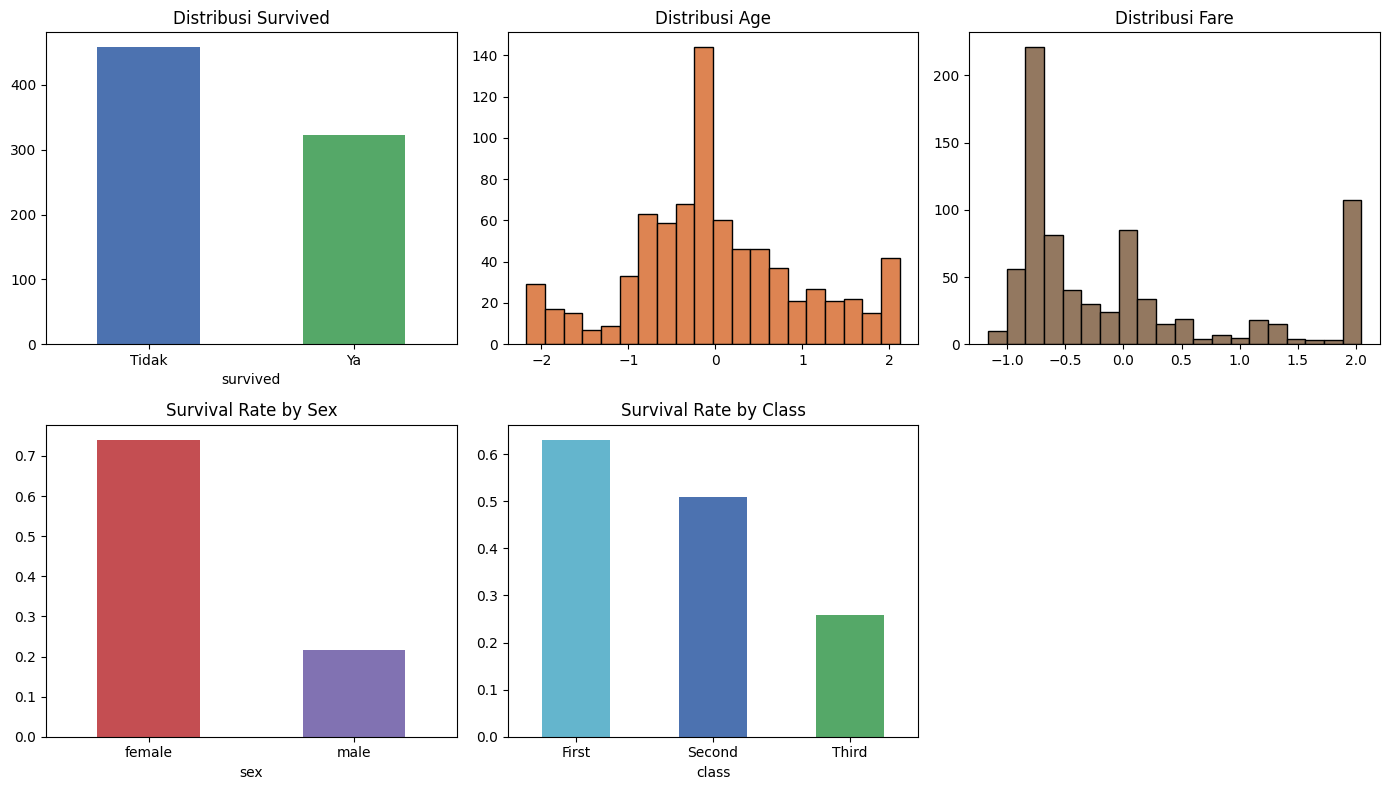

In [15]:
# 5. EDA Visualisasi
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# 1 Distribusi survived
df["survived"].value_counts().plot(
    kind="bar",
    ax=axes[0, 0],
    color=["#4C72B0", "#55A868"]
)
axes[0, 0].set_title("Distribusi Survived")
axes[0, 0].set_xticklabels(["Tidak", "Ya"], rotation=0)

# 2 Distribusi age
axes[0, 1].hist(
    df["age"],
    bins=20,
    color="#DD8452",
    edgecolor="black"
)
axes[0, 1].set_title("Distribusi Age")

# 3 Distribusi fare
axes[0, 2].hist(
    df["fare"],
    bins=20,
    color="#937860",
    edgecolor="black"
)
axes[0, 2].set_title("Distribusi Fare")

# 4 Survival rate by sex
df.groupby("sex")["survived"].mean().plot(
    kind="bar",
    ax=axes[1, 0],
    color=["#C44E52", "#8172B2"]
)
axes[1, 0].set_title("Survival Rate by Sex")
axes[1, 0].set_xticklabels(["female", "male"], rotation=0)

# 5 Survival rate by class
df.groupby("class")["survived"].mean().plot(
    kind="bar",
    ax=axes[1, 1],
    color=["#64B5CD", "#4C72B0", "#55A868"]
)
axes[1, 1].set_title("Survival Rate by Class")
axes[1, 1].set_xticklabels(["First", "Second", "Third"], rotation=0)
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

plt.savefig("pertemuan02_eda.png")
plt.close()

In [16]:
# 5 Insight
print("\n=== 5 Insight ===")
surv_rate = df["survived"].mean()
print(f"1. Tingkat survival keseluruhan: {surv_rate:.1%}")
print(f"2. Survival rate perempuan ({df[df['sex']=='female']['survived'].mean():.1%}) "
      f"jauh lebih tinggi daripada laki-laki ({df[df['sex']=='male']['survived'].mean():.1%}).")
print(f"3. Penumpang kelas 1 memiliki survival rate tertinggi "
      f"({df[df['class']=='First']['survived'].mean():.1%}).")
print(f"4. Median age setelah scaling mendekati 0 (mean={df['age'].mean():.3f}), sesuai harapan StandardScaler.")
print(f"5. Setelah clipping, fare tidak lagi memiliki outlier ekstrem.")



=== 5 Insight ===
1. Tingkat survival keseluruhan: 41.4%
2. Survival rate perempuan (74.1%) jauh lebih tinggi daripada laki-laki (21.7%).
3. Penumpang kelas 1 memiliki survival rate tertinggi (63.1%).
4. Median age setelah scaling mendekati 0 (mean=0.000), sesuai harapan StandardScaler.
5. Setelah clipping, fare tidak lagi memiliki outlier ekstrem.
